<a href="https://colab.research.google.com/github/brittanybee-alt/Capstone-Project-Two/blob/main/Capstone_Two_EDA_%5BBrittany_Barrion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/cleaned_data_CapstoneBLB.csv")   # keeps tract as text
outcome = "Household_Income_at_Age_35_rP_gP_p25"
print(df.shape)
df.head()

(406, 16)


,tract,Name,Household_Income_at_Age_35_rP_gP_p25,Median_Rent_2012-16,Median_Hhold._Income_of_Residents_in_2012-16,Median_Hhold._Income_of_Residents_in_1990,Poverty_Rate_in_2012-16,Fraction_College_Graduates_in_2012-16,Fraction_Non-White_in_2010,Foreign-Born_Share_in_2012-16,Fraction_Single_Parents_in_2012-16,Population_Density_in_2010,Density_of_Jobs_in_2013,Fraction_with_Short_Work_Commutes_in_2012-16,Census_Response_Rate_Social_Capital_Proxy,state
0,51013100400,"Arlington, VA",68322.0,3501.0,202909.0,162342,0.0286,0.8635,0.1214,0.1138,0.0941,2358.0,120.5,0.2106,91.2,VA
1,51013101601,"North Highland, Arlington, VA",65785.0,1982.0,119122.0,74114,0.1455,0.8462,0.2323,0.1876,0.2963,4899.0,2037.0,0.1230,79.5,VA
2,51510200702,"Eisenhower East, Alexandria, VA",64583.0,2186.0,110481.0,64247,0.0222,0.8253,0.3072,0.1373,0.4101,8445.0,13782.0,0.1798,82.1,VA
3,24031705300,"Chevy Chase, MD",63907.0,3375.0,246886.0,232485,0.0183,0.8910,0.0675,0.1335,0.0656,4656.0,1619.0,0.1481,91.8,MD
4,51510202001,"Old Town, Alexandria, VA",62664.0,2750.0,174054.0,140144,0.0115,0.8876,0.0729,0.0944,0.1842,11405.0,4411.0,0.2172,86.3,VA


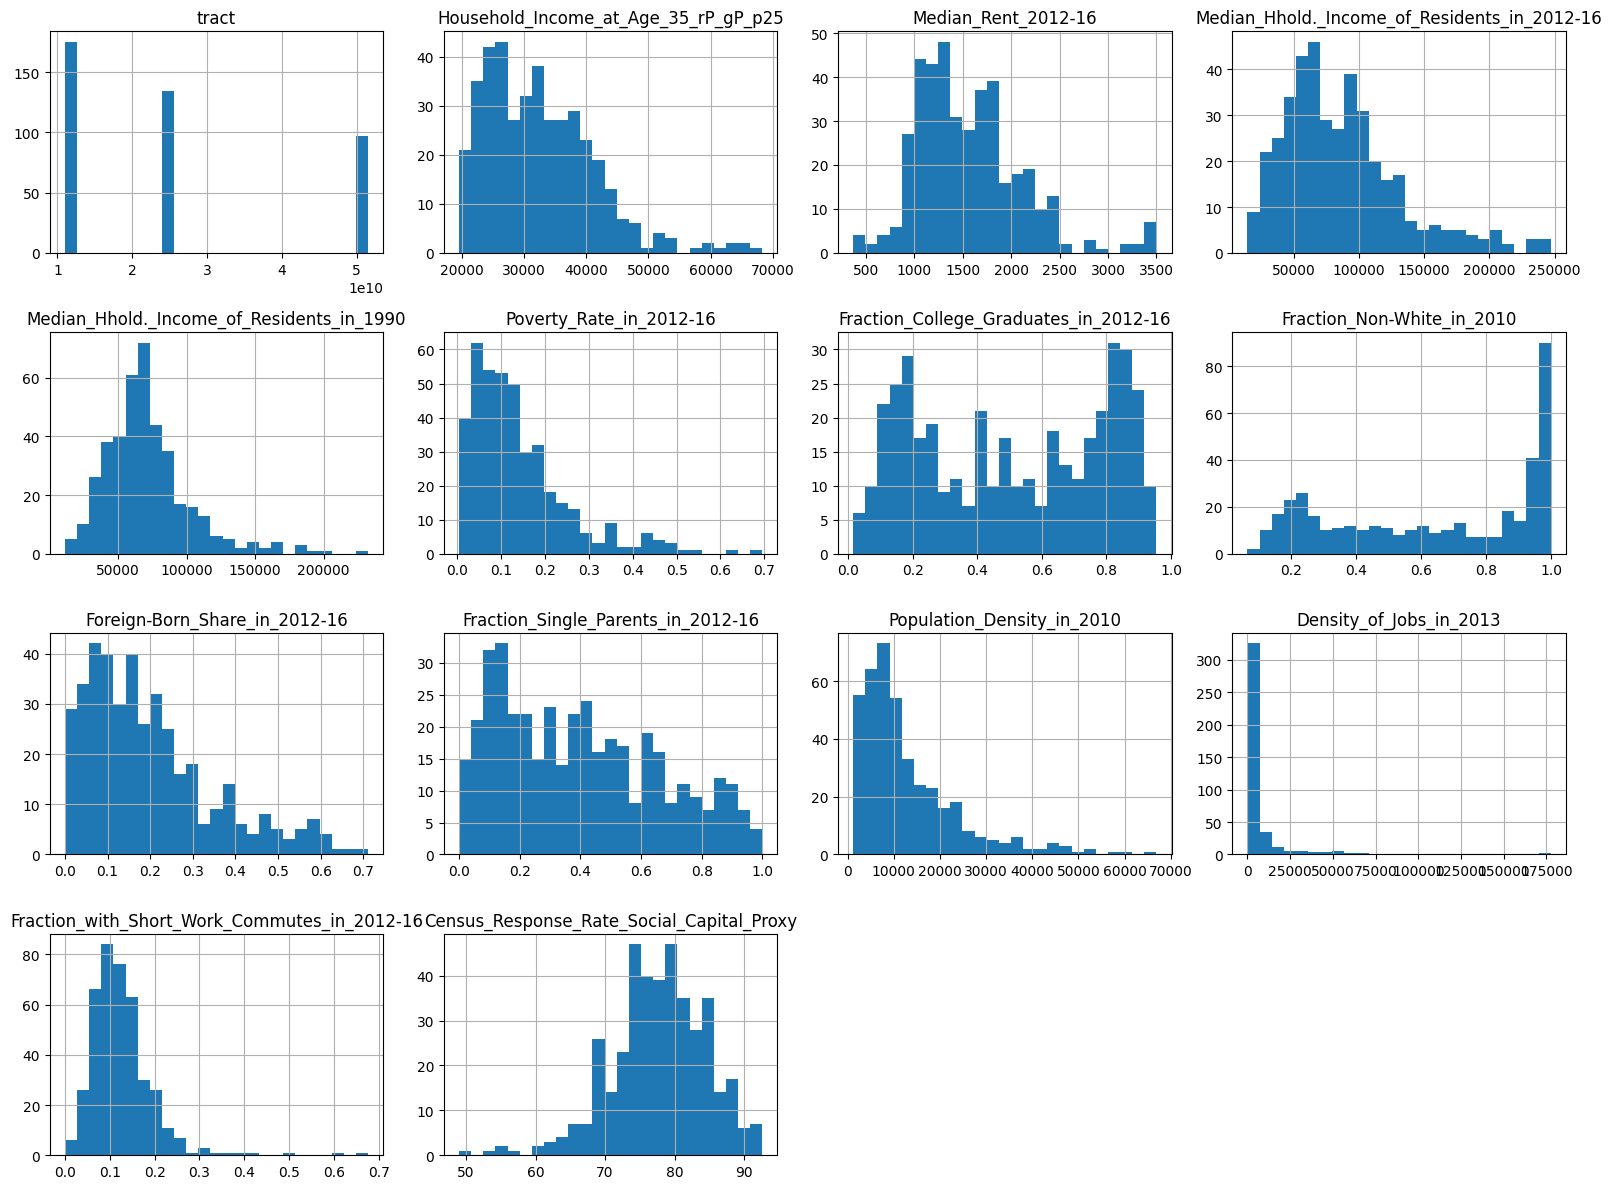

In [2]:
num_cols = df.select_dtypes("number").columns
df[num_cols].hist(figsize=(16, 12), bins=25)
plt.tight_layout()
plt.show()

In [3]:
num_cols = df.select_dtypes("number").columns.drop("tract")

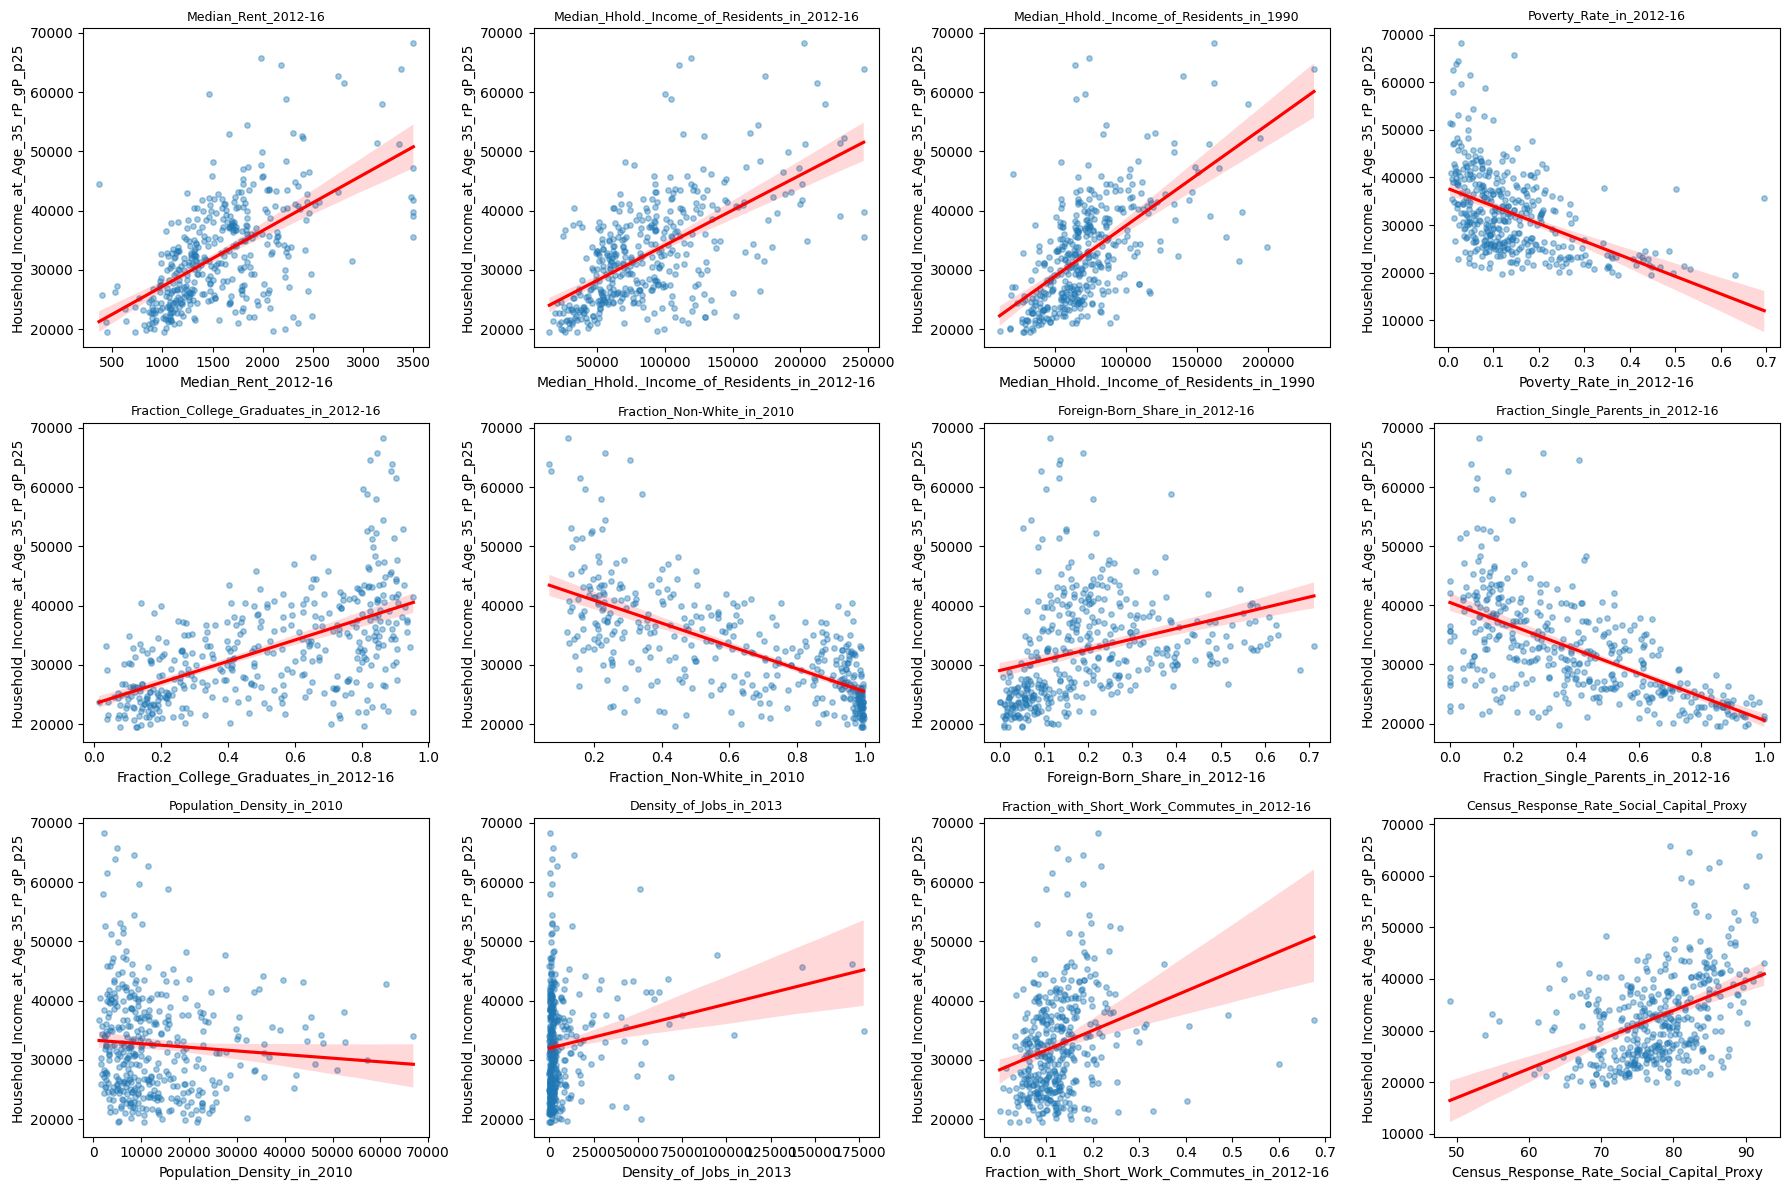

In [4]:
predictors = [c for c in num_cols if c != outcome]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, col in zip(axes.flat, predictors):
    sns.regplot(data=df, x=col, y=outcome, ax=ax,
                scatter_kws={"alpha": 0.4, "s": 15},
                line_kws={"color": "red"})
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
corr = pd.DataFrame({
    "pearson": df[predictors].corrwith(df[outcome]),
    "spearman": df[predictors].corrwith(df[outcome], method="spearman")
}).sort_values("pearson")
corr.round(2)

,pearson,spearman
Fraction_Non-White_in_2010,-0.68,-0.72
Fraction_Single_Parents_in_2012-16,-0.60,-0.63
Poverty_Rate_in_2012-16,-0.47,-0.51
Population_Density_in_2010,-0.08,-0.13
Density_of_Jobs_in_2013,0.16,0.16
Fraction_with_Short_Work_Commutes_in_2012-16,0.27,0.34
Foreign-Born_Share_in_2012-16,0.30,0.52
Census_Response_Rate_Social_Capital_Proxy,0.44,0.46
Fraction_College_Graduates_in_2012-16,0.58,0.60
Median_Rent_2012-16,0.59,0.59


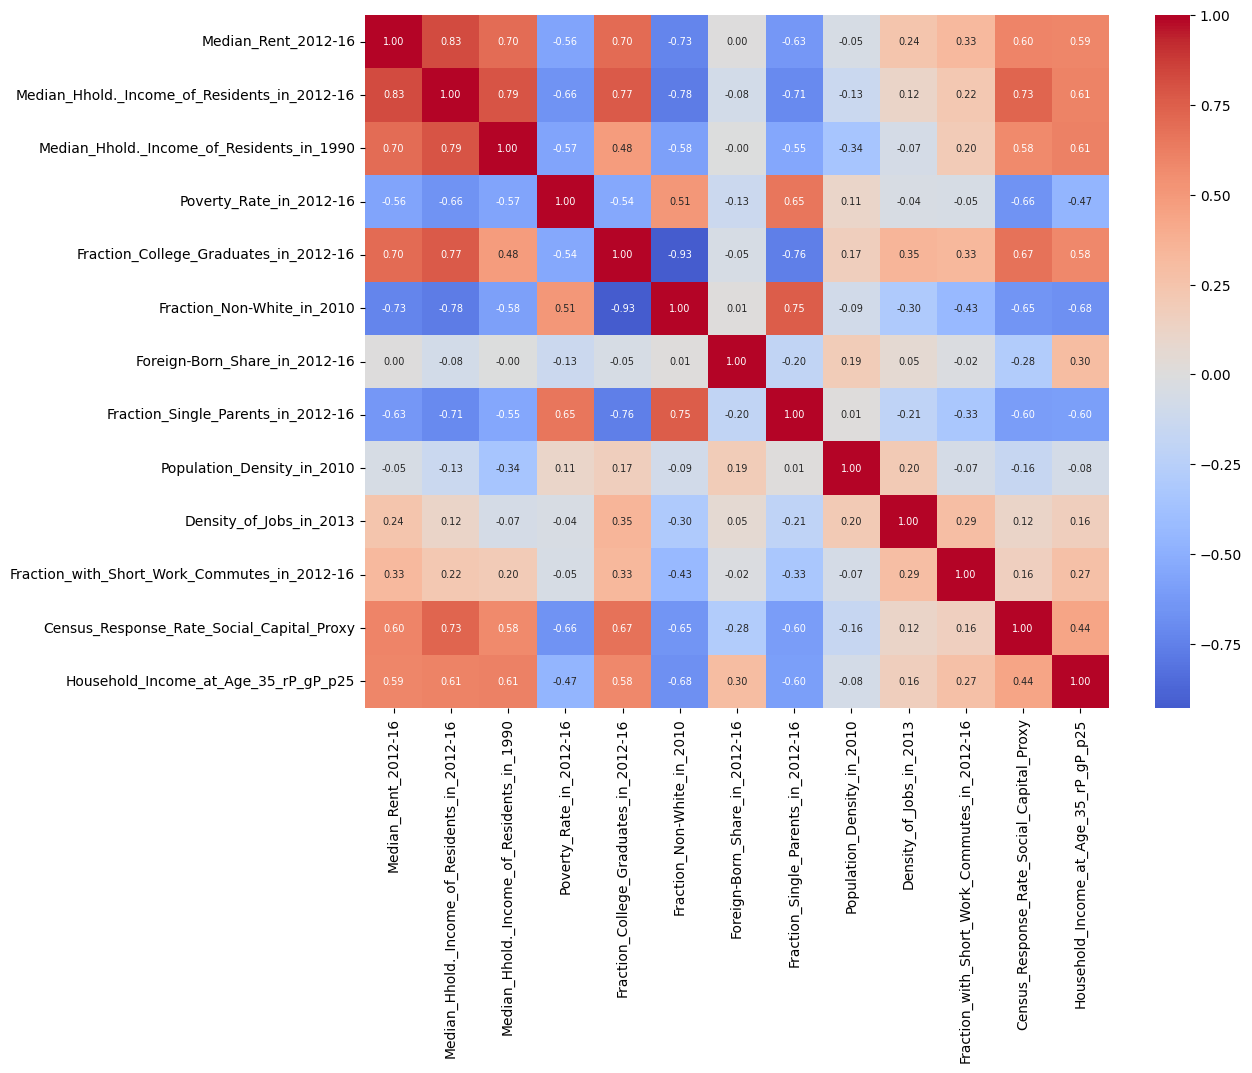

In [7]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[predictors + [outcome]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.show()

In [9]:
from scipy import stats
pd.options.display.float_format = "{:.3g}".format

rows = []
for c in predictors:
    r, p = stats.pearsonr(df[c], df[outcome])
    rho, p_s = stats.spearmanr(df[c], df[outcome])
    rows.append({"feature": c, "pearson_r": r, "pearson_p": p,
                 "spearman_rho": rho, "spearman_p": p_s})
pd.DataFrame(rows).sort_values("pearson_r")

,feature,pearson_r,pearson_p,spearman_rho,spearman_p
5,Fraction_Non-White_in_2010,-0.678,6.72e-56,-0.716,5.89e-65
7,Fraction_Single_Parents_in_2012-16,-0.596,1.89e-40,-0.629,4.32e-46
3,Poverty_Rate_in_2012-16,-0.466,2.89e-23,-0.511,2.49e-28
8,Population_Density_in_2010,-0.0752,0.13,-0.126,0.0112
9,Density_of_Jobs_in_2013,0.164,0.000904,0.164,0.000936
10,Fraction_with_Short_Work_Commutes_in_2012-16,0.271,3.04e-08,0.336,3.57e-12
6,Foreign-Born_Share_in_2012-16,0.302,5.59e-10,0.522,1.06e-29
11,Census_Response_Rate_Social_Capital_Proxy,0.437,2.47e-20,0.457,2.66e-22
4,Fraction_College_Graduates_in_2012-16,0.578,1.37e-37,0.599,6.41e-41
0,Median_Rent_2012-16,0.591,1.54e-39,0.594,5.04e-40


       count     mean   median
state                         
DC       175 2.83e+04 2.66e+04
MD       134 3.29e+04 3.19e+04
VA        97 3.98e+04 3.87e+04


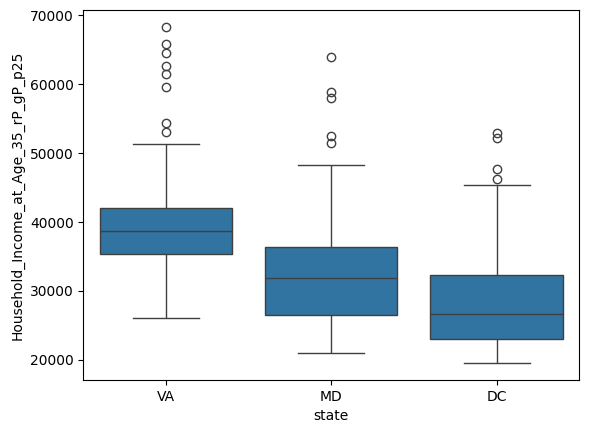

F_onewayResult(statistic=np.float64(71.72207669615894), pvalue=np.float64(2.2567912684742476e-27))
KruskalResult(statistic=np.float64(120.87661852150532), pvalue=np.float64(5.649054861905148e-27))


In [10]:
# Subgroups: DC vs MD vs VA
print(df.groupby("state")[outcome].agg(["count", "mean", "median"]).round(0))

sns.boxplot(data=df, x="state", y=outcome)
plt.show()

groups = [g[outcome].values for _, g in df.groupby("state")]
print(stats.f_oneway(*groups))   # ANOVA
print(stats.kruskal(*groups))    # rank-based, safer for skewed data

In [11]:
from itertools import combinations
pairs = list(combinations(df["state"].unique(), 2))
for a, b in pairs:
    x = df.loc[df.state == a, outcome]; y = df.loc[df.state == b, outcome]
    p = stats.mannwhitneyu(x, y).pvalue * len(pairs)   # Bonferroni correction
    print(a, "vs", b, "p =", min(p, 1))

VA vs MD p = 4.040652394877359e-11
VA vs DC p = 8.50723430261786e-24
MD vs DC p = 9.86327937091941e-09


In [14]:
skewed = ["Density_of_Jobs_in_2013", "Population_Density_in_2010",
          "Foreign-Born_Share_in_2012-16", "Poverty_Rate_in_2012-16"]
comp = [{"feature": c,
         "skew_before": df[c].skew(), "skew_after": np.log1p(df[c]).skew(),
         "r_before": df[c].corr(df[outcome]),
         "r_after": np.log1p(df[c]).corr(df[outcome])} for c in skewed]
pd.DataFrame(comp).round(2)

,feature,skew_before,skew_after,r_before,r_after
0,Density_of_Jobs_in_2013,5.23,0.03,0.16,0.18
1,Population_Density_in_2010,1.87,-0.04,-0.08,-0.14
2,Foreign-Born_Share_in_2012-16,1.08,0.83,0.3,0.32
3,Poverty_Rate_in_2012-16,1.67,1.35,-0.47,-0.48


In [15]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(df[predictors])
vif = pd.DataFrame({"feature": X.columns,
                    "VIF": [variance_inflation_factor(X.values, i)
                            for i in range(X.shape[1])]})
vif[vif.feature != "const"].sort_values("VIF", ascending=False).round(1)

,feature,VIF
5,Fraction_College_Graduates_in_2012-16,11.9
6,Fraction_Non-White_in_2010,10.6
2,Median_Hhold._Income_of_Residents_in_2012-16,7.6
3,Median_Hhold._Income_of_Residents_in_1990,4.1
1,Median_Rent_2012-16,3.8
8,Fraction_Single_Parents_in_2012-16,3.7
12,Census_Response_Rate_Social_Capital_Proxy,3.4
4,Poverty_Rate_in_2012-16,2.8
7,Foreign-Born_Share_in_2012-16,1.7
9,Population_Density_in_2010,1.6


In [23]:
dropped = ["Fraction_College_Graduates_in_2012-16",
           "Median_Hhold._Income_of_Residents_in_2012-16"]
df_fe = df.drop(columns=dropped).copy()

# log-transform the two heavily skewed density features
df_fe["log_job_density"] = np.log1p(df_fe["Density_of_Jobs_in_2013"])
df_fe["log_pop_density"] = np.log1p(df_fe["Population_Density_in_2010"])
df_fe = df_fe.drop(columns=["Density_of_Jobs_in_2013", "Population_Density_in_2010"])

# one-hot encode state (DC is the baseline)
df_fe = pd.get_dummies(df_fe, columns=["state"], prefix="state", drop_first=True)

print(df_fe.shape)
df_fe.head()

(406, 15)


,tract,Name,Household_Income_at_Age_35_rP_gP_p25,Median_Rent_2012-16,Median_Hhold._Income_of_Residents_in_1990,Poverty_Rate_in_2012-16,Fraction_Non-White_in_2010,Foreign-Born_Share_in_2012-16,Fraction_Single_Parents_in_2012-16,Fraction_with_Short_Work_Commutes_in_2012-16,Census_Response_Rate_Social_Capital_Proxy,log_job_density,log_pop_density,state_MD,state_VA
0,51013100400,"Arlington, VA",6.83e+04,3.5e+03,162342,0.0286,0.121,0.114,0.0941,0.211,91.2,4.8,7.77,False,True
1,51013101601,"North Highland, Arlington, VA",6.58e+04,1.98e+03,74114,0.145,0.232,0.188,0.296,0.123,79.5,7.62,8.5,False,True
2,51510200702,"Eisenhower East, Alexandria, VA",6.46e+04,2.19e+03,64247,0.0222,0.307,0.137,0.41,0.18,82.1,9.53,9.04,False,True
3,24031705300,"Chevy Chase, MD",6.39e+04,3.38e+03,232485,0.0183,0.0675,0.134,0.0656,0.148,91.8,7.39,8.45,True,False
4,51510202001,"Old Town, Alexandria, VA",6.27e+04,2.75e+03,140144,0.0115,0.0729,0.0944,0.184,0.217,86.3,8.39,9.34,False,True


In [24]:
import os

os.makedirs("data/processed", exist_ok=True)
df_fe.to_csv("data/processed/eda_features.csv", index=False)

final_preds = [c for c in df_fe.select_dtypes("number").columns
               if c not in ["tract", outcome] and not c.startswith("state_")]
X = sm.add_constant(df_fe[final_preds])
pd.DataFrame({"feature": X.columns[1:],
              "VIF": [variance_inflation_factor(X.values, i)
                      for i in range(1, X.shape[1])]}).round(1)

,feature,VIF
0,Median_Rent_2012-16,3
1,Median_Hhold._Income_of_Residents_in_1990,3.4
2,Poverty_Rate_in_2012-16,2.7
3,Fraction_Non-White_in_2010,4.8
4,Foreign-Born_Share_in_2012-16,1.6
5,Fraction_Single_Parents_in_2012-16,3.4
6,Fraction_with_Short_Work_Commutes_in_2012-16,1.5
7,Census_Response_Rate_Social_Capital_Proxy,3.4
8,log_job_density,1.6
9,log_pop_density,1.8


In [25]:
df_fe[["state_MD", "state_VA"]] = df_fe[["state_MD", "state_VA"]].astype(int)
df_fe.to_csv("data/processed/eda_features.csv", index=False)

1. Which variables best explain the outcome? Fraction non-white, income 1990, single-parent share, and rent, followed by poverty and census response.

2. Do subgroups differ? Yes, by state: Virginia is highest, then Maryland, then DC.

3. Which correlations are strong? The strongest with the outcome are listed above. Among predictors, college and non-white (-0.93), and rent and income 2012-16 (0.83).

4. Which tests fit? Pearson and Spearman for correlations, ANOVA and Kruskal-Wallis for state differences, and Mann-Whitney with correction for pairs. VIF checked overlap between features.